In [92]:
import sys
print(sys.executable)


/opt/anaconda3/envs/credit-risk/bin/python


In [93]:
import pandas as pd
import os

BASE = os.path.expanduser("~/Projects/credit-risk-platform/data/raw/home-credit-default-risk/")

app = pd.read_csv(BASE + "application_train.csv")

print(app.shape)
app.head()


(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [94]:
rows, cols = app.shape

default_rate = app["TARGET"].mean()

print("Rows:", rows)
print("Columns:", cols)
print("Default rate:", round(default_rate, 4))


Rows: 307511
Columns: 122
Default rate: 0.0807


In [95]:
bureau = pd.read_csv(BASE + "bureau.csv")

print(bureau.shape)
bureau.head()


(1716428, 17)


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [96]:
bureau_agg = (
    bureau
    .groupby("SK_ID_CURR")
    .agg(
        bureau_loans_count=("SK_ID_BUREAU", "count"),
        bureau_credit_sum=("AMT_CREDIT_SUM", "sum"),
        bureau_credit_debt=("AMT_CREDIT_SUM_DEBT", "sum"),
        bureau_overdue_sum=("AMT_CREDIT_SUM_OVERDUE", "sum"),
        bureau_active_mean=("CREDIT_ACTIVE", lambda x: (x == "Active").mean())
    )
    .reset_index()
)

bureau_agg.head()


,SK_ID_CURR,bureau_loans_count,bureau_credit_sum,bureau_credit_debt,bureau_overdue_sum,bureau_active_mean
0,100001,7,1453365.000,596686.5,0.0,0.428571
1,100002,8,865055.565,245781.0,0.0,0.250000
2,100003,4,1017400.500,0.0,0.0,0.250000
3,100004,2,189037.800,0.0,0.0,0.000000
4,100005,3,657126.000,568408.5,0.0,0.666667


In [97]:
app_fe = app.merge(bureau_agg, on="SK_ID_CURR", how="left")

print(app_fe.shape)


(307511, 127)


In [98]:
prev = pd.read_csv(BASE + "previous_application.csv")

print(prev.shape)
prev.head()


(1670214, 37)


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [99]:
prev_agg = (
    prev
    .groupby("SK_ID_CURR")
    .agg(
        prev_apps_count=("SK_ID_PREV", "count"),
        prev_amt_app_mean=("AMT_APPLICATION", "mean"),
        prev_amt_credit_mean=("AMT_CREDIT", "mean"),
        prev_refused_rate=("NAME_CONTRACT_STATUS", lambda x: (x == "Refused").mean()),
        prev_approved_rate=("NAME_CONTRACT_STATUS", lambda x: (x == "Approved").mean()),
        prev_days_decision_mean=("DAYS_DECISION", "mean"),
        prev_down_payment_mean=("AMT_DOWN_PAYMENT", "mean")
    )
    .reset_index()
)

prev_agg.head()


,SK_ID_CURR,prev_apps_count,prev_amt_app_mean,prev_amt_credit_mean,prev_refused_rate,prev_approved_rate,prev_days_decision_mean,prev_down_payment_mean
0,100001,1,24835.50,23787.00,0.0,1.0,-1740.0,2520.0
1,100002,1,179055.00,179055.00,0.0,1.0,-606.0,0.0
2,100003,3,435436.50,484191.00,0.0,1.0,-1305.0,3442.5
3,100004,1,24282.00,20106.00,0.0,1.0,-815.0,4860.0
4,100005,2,22308.75,20076.75,0.0,0.5,-536.0,4464.0


In [100]:
app_fe = app_fe.merge(prev_agg, on="SK_ID_CURR", how="left")

print(app_fe.shape)


(307511, 134)


In [101]:
inst = pd.read_csv(BASE + "installments_payments.csv")

print(inst.shape)
inst.head()


(13605401, 8)


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


In [102]:
inst["days_late"] = inst["DAYS_ENTRY_PAYMENT"] - inst["DAYS_INSTALMENT"]
inst["amt_gap"] = inst["AMT_INSTALMENT"] - inst["AMT_PAYMENT"]

inst_agg = (
    inst
    .groupby("SK_ID_CURR")
    .agg(
        inst_count=("SK_ID_PREV", "count"),
        late_rate=("days_late", lambda x: (x > 0).mean()),
        avg_days_late=("days_late", lambda x: x[x > 0].mean()),
        max_days_late=("days_late", "max"),
        avg_amt_gap=("amt_gap", "mean"),
        missed_payment_rate=("amt_gap", lambda x: (x > 0).mean())
    )
    .reset_index()
)

inst_agg.head()


,SK_ID_CURR,inst_count,late_rate,avg_days_late,max_days_late,avg_amt_gap,missed_payment_rate
0,100001,7,0.142857,11.0,11.0,0.0,0.0
1,100002,19,0.000000,NaN,-12.0,0.0,0.0
2,100003,25,0.000000,NaN,-1.0,0.0,0.0
3,100004,3,0.000000,NaN,-3.0,0.0,0.0
4,100005,9,0.111111,1.0,1.0,0.0,0.0


In [103]:
app_fe = app_fe.merge(inst_agg, on="SK_ID_CURR", how="left")

print(app_fe.shape)


(307511, 140)


In [104]:
app_fe = app_fe.fillna(0)


In [105]:
y = app_fe["TARGET"]
X = app_fe.drop(columns=["TARGET"])


In [106]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)


(246008, 139) (61503, 139)


In [107]:
import numpy as np
import pandas as pd

def mixed_type_cols(df, max_check=20000):
    df_s = df.sample(min(len(df), max_check), random_state=42)
    bad = []
    for c in df_s.columns:
        types = df_s[c].dropna().map(type).unique()
        if len(types) > 1:
            bad.append((c, [t.__name__ for t in types]))
    return bad

bad = mixed_type_cols(X)
print("Mixed-type columns:", len(bad))
bad[:30]


Mixed-type columns: 6


[('NAME_TYPE_SUITE', ['str', 'int']),
 ('OCCUPATION_TYPE', ['str', 'int']),
 ('FONDKAPREMONT_MODE', ['int', 'str']),
 ('HOUSETYPE_MODE', ['int', 'str']),
 ('WALLSMATERIAL_MODE', ['int', 'str']),
 ('EMERGENCYSTATE_MODE', ['int', 'str'])]

In [108]:
bad_cols = [c for c,_ in bad]

# Force ALL mixed-type cols to clean strings
X[bad_cols] = X[bad_cols].astype("string").fillna("Missing")
      

In [109]:
import numpy as np

categorical_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# Anything not numeric becomes categorical
categorical_cols = [c for c in X.columns if c not in numerical_cols]

print("Numerical:", len(numerical_cols))
print("Categorical:", len(categorical_cols))
print("Bad fixed:", len(bad_cols))


Numerical: 123
Categorical: 16
Bad fixed: 6


In [110]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

y = app_fe["TARGET"]
X = X  # (your fixed X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ],
    remainder="drop"
)

pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(max_iter=3000, class_weight="balanced"))
])

pipe.fit(X_train, y_train)

y_proba = pipe.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test,y_proba))
print("PR-AUC:", average_precision_score(y_test,y_proba))


ROC-AUC: 0.7504498770034694
PR-AUC: 0.2309291381185296


In [111]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.9, 0.05)

for t in thresholds:
    preds = (y_proba >= t).astype(int)
    p = precision_score(y_test, preds)
    r = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    print(f"t={t:.2f} | Precision={p:.3f} Recall={r:.3f} F1={f1:.3f}")


t=0.10 | Precision=0.083 Recall=0.998 F1=0.153
t=0.15 | Precision=0.086 Recall=0.987 F1=0.159
t=0.20 | Precision=0.092 Recall=0.970 F1=0.169
t=0.25 | Precision=0.100 Recall=0.944 F1=0.180
t=0.30 | Precision=0.109 Recall=0.909 F1=0.194
t=0.35 | Precision=0.120 Recall=0.865 F1=0.210
t=0.40 | Precision=0.132 Recall=0.812 F1=0.227
t=0.45 | Precision=0.146 Recall=0.753 F1=0.245
t=0.50 | Precision=0.163 Recall=0.686 F1=0.263
t=0.55 | Precision=0.182 Recall=0.608 F1=0.280
t=0.60 | Precision=0.200 Recall=0.521 F1=0.290
t=0.65 | Precision=0.226 Recall=0.433 F1=0.297
t=0.70 | Precision=0.252 Recall=0.339 F1=0.289
t=0.75 | Precision=0.287 Recall=0.251 F1=0.268
t=0.80 | Precision=0.329 Recall=0.161 F1=0.217
t=0.85 | Precision=0.401 Recall=0.087 F1=0.143


In [112]:
from sklearn.metrics import confusion_matrix, classification_report

t = 0.35
preds = (y_proba >= t).astype(int)

print(confusion_matrix(y_test, preds))
print(classification_report(y_test, preds))


[[24981 31557]
 [  670  4295]]
              precision    recall  f1-score   support

           0       0.97      0.44      0.61     56538
           1       0.12      0.87      0.21      4965

    accuracy                           0.48     61503
   macro avg       0.55      0.65      0.41     61503
weighted avg       0.90      0.48      0.58     61503



In [113]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

xgb_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight= (y_train==0).sum()/(y_train==1).sum(),
        eval_metric="auc",
        random_state=42
    ))
])

xgb_pipe.fit(X_train, y_train)

y_proba_xgb = xgb_pipe.predict_proba(X_test)[:,1]


In [114]:
from sklearn.metrics import roc_auc_score, average_precision_score

print("XGB ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))
print("XGB PR-AUC:", average_precision_score(y_test, y_proba_xgb))


XGB ROC-AUC: 0.7738981993484619
XGB PR-AUC: 0.26953822181272297


In [115]:
import joblib

joblib.dump(xgb_pipe, "credit_risk_xgb_pipeline.pkl")


['credit_risk_xgb_pipeline.pkl']

In [116]:
joblib.dump(pipe, "credit_risk_logistic_pipeline.pkl")


['credit_risk_logistic_pipeline.pkl']

In [117]:
from sklearn.metrics import confusion_matrix, classification_report

t = 0.35
preds = (y_proba >= t).astype(int)

print(confusion_matrix(y_test, preds))
print(classification_report(y_test, preds))


[[24981 31557]
 [  670  4295]]
              precision    recall  f1-score   support

           0       0.97      0.44      0.61     56538
           1       0.12      0.87      0.21      4965

    accuracy                           0.48     61503
   macro avg       0.55      0.65      0.41     61503
weighted avg       0.90      0.48      0.58     61503



In [120]:
import pandas as pd
import matplotlib.pyplot as plt

xgb_model = xgb_pipe.named_steps["clf"]

importance = xgb_model.get_booster().get_score(importance_type="gain")

importance_df = (
    pd.DataFrame({
        "feature": list(importance.keys()),
        "importance_gain": list(importance.values())
    })
    .sort_values("importance_gain", ascending=False)
    .head(20)
)

importance_df

,feature,importance_gain
29,f30,391.718475
28,f29,385.345428
224,f248,304.334076
135,f149,239.761642
131,f143,218.253983
118,f126,194.498184
117,f125,162.823288
78,f80,157.753830
27,f28,146.304184
105,f113,146.159195


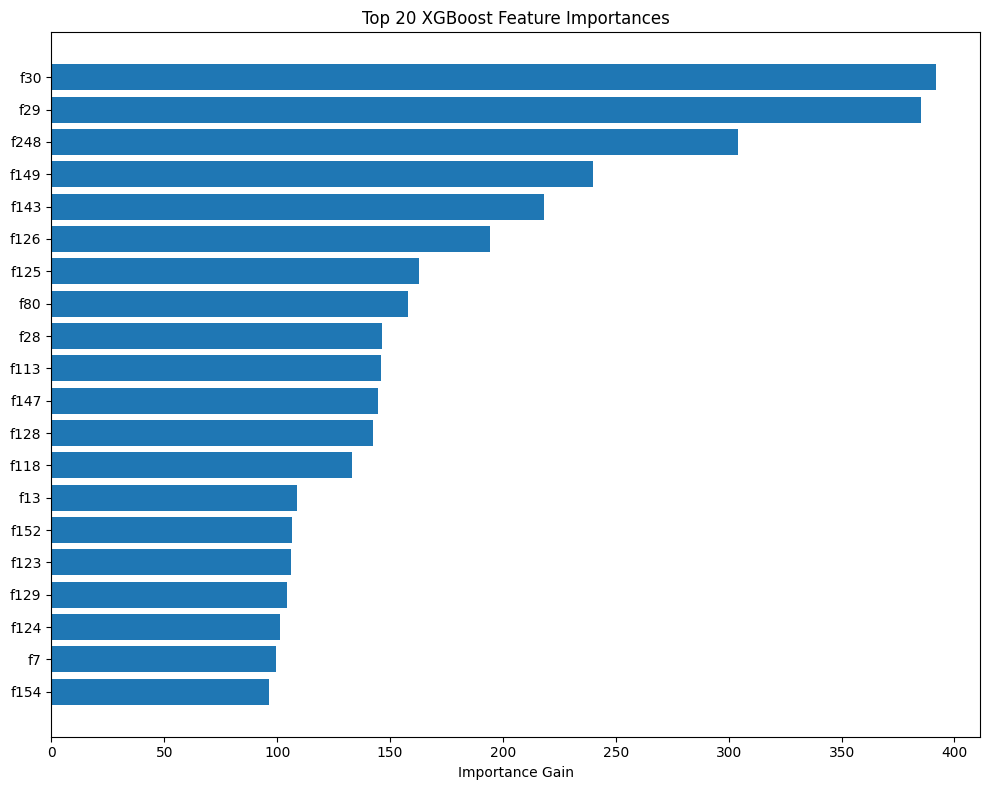

In [121]:
plt.figure(figsize=(10, 8))
plt.barh(importance_df["feature"][::-1], importance_df["importance_gain"][::-1])
plt.xlabel("Importance Gain")
plt.title("Top 20 XGBoost Feature Importances")
plt.tight_layout()
plt.savefig("outputs/xgb_feature_importance_top20.png", dpi=300, bbox_inches="tight")
plt.show()